In [1]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

In [2]:
COL = '/Volumes/easystore/proton-deuteron/col&ind/col.pkl'                               # collection plane protons and deuterons
IND = '/Volumes/easystore/proton-deuteron/col&ind/ind.pkl'                               # induction plane matching clusters

P_COL = '/Volumes/easystore/proton-deuteron/col&ind/pickyprotonscol.pkl'
P_IND = '/Volumes/easystore/proton-deuteron/col&ind/pickyprotonsind.pkl'

masses = pd.read_csv('/Volumes/easystore/proton-deuteron/csv/picky+match.csv')           # BEAMLINE INFO. e.g. mass, if no. of particles = 1

col = pd.read_pickle(COL) 
ind = pd.read_pickle(IND)

p_col = pd.read_pickle(P_COL)
p_ind = pd.read_pickle(P_IND)

d_col = col[col['particle_type'] == 'deuteron']
d_ind = ind[ind['particle_type'] == 'deuteron']

col = pd.concat([d_col, p_col], ignore_index=True)
ind = pd.concat([d_ind, p_ind], ignore_index=True)

col = pd.merge(
    col,
    masses[['run', 'subrun', 'event', 'p', 'm', 'beamline_mass']],
    on=['run', 'subrun', 'event'],
    how='left'
)

ind = pd.merge(
    ind,
    masses[['run', 'subrun', 'event', 'p', 'm', 'beamline_mass']],
    on=['run', 'subrun', 'event'],
    how='left'
)

print(ind.shape, col.shape)

(12915, 38) (12915, 38)


In [3]:
maxes = col['column_maxes'].values                                                  # max ADC for each wire hit

normalised = []

for i, signal in enumerate(maxes):  # normalise 0–1 per cluster using max
    minimum = 0
    maximum = np.max(signal)

    if maximum > minimum:
        normalised_signal = (signal - minimum) / (maximum - minimum)
    else:
        normalised_signal = np.zeros_like(signal, dtype=float)
        print(f'Error: Max not greater than min in signal {i}.')

    normalised.append(normalised_signal[:-1])

col['normalised'] = normalised
residual_range = [list(range(len(cluster)-1, -1, -1)) for cluster in col['normalised'].values]
col['rr'] = residual_range

adcdiff = [np.diff(signal) for signal in normalised]                                # difference between consecutive hits
maxdiff = [np.max(d) if d.size > 0 else 0.0 for d in adcdiff]; col['maxdiff'] = maxdiff              # max ADC difference

maxes = ind['column_maxes'].values                                                  # for induction plane

normalised = []

for i, signal in enumerate(maxes):
    
    minimum = 0
    maximum = np.max(signal)

    if maximum > minimum:
        normalised_signal = (signal - minimum) / (maximum - minimum)
    else:
        normalised_signal = np.zeros_like(signal, dtype=float)
        print(f'Error: Max not greater than min in signal {i}.')

    normalised.append(normalised_signal[:-1])

adcdiff = [np.diff(signal) for signal in normalised]
maxdiff = [np.max(d) if d.size > 0 else 0.0 for d in adcdiff]; ind['maxdiff'] = maxdiff

removed_indices_col = col[~(col['maxdiff'] >= 0)].index
removed_indices_ind = ind[~(ind['maxdiff'] >= 0)].index

removed_indices = removed_indices_col.union(removed_indices_ind)

col = col[~col.index.isin(removed_indices)]; print(col.shape)
ind = ind[~ind.index.isin(removed_indices)]; print(ind.shape)

removed_indices_col = col[~((col['height'] < 100) & (col['width'] < 400))].index            # remove long and wide images
removed_indices_ind = ind[~((ind['height'] < 100) & (ind['width'] < 400))].index


removed_indices = removed_indices_col.union(removed_indices_ind)

col = col[~col.index.isin(removed_indices)]; print(col.shape)
ind = ind[~ind.index.isin(removed_indices)]; print(ind.shape)

(12883, 41)
(12883, 39)
(10888, 41)
(10888, 39)


In [4]:
p_m = col[col['particle_type'] == 'proton']['beamline_mass'].values
d_m = col[col['particle_type'] == 'deuteron']['beamline_mass'].values

d_l = col[col['particle_type'] == 'deuteron']['height'].values
d_p = col[col['particle_type'] == 'deuteron']['p'].values

In [5]:
deuterons = col[(col['particle_type'] == 'deuteron') & (col['p'] == 1) & (col['height'] < 15)] #  
protons = col[(col['particle_type'] == 'proton') & (col['p'] == 1 & (col['height'] < 15))]

In [6]:
dE = deuterons['normalised'].to_list()
dr = deuterons['rr'].to_list()

pE = protons['normalised'].to_list()
pr = protons['rr'].to_list()

In [7]:
dE = np.concatenate(dE)   # shape: (N * D,)
dr = np.concatenate(dr)

pE = np.concatenate(pE)   # shape: (N * D,)
pr = np.concatenate(pr)

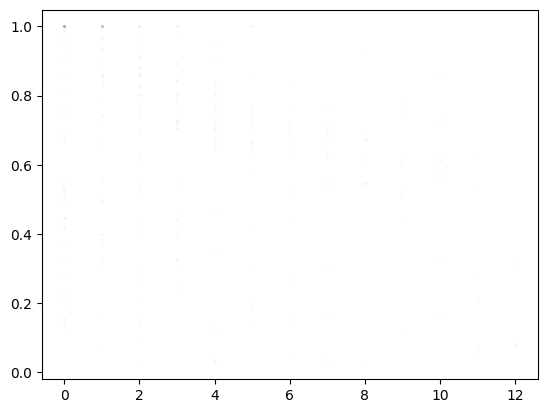

In [8]:
plt.scatter(dr, dE, s=0.001)

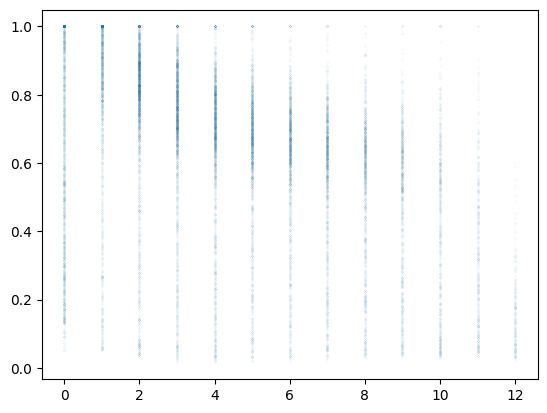

In [9]:
plt.scatter(pr, pE, s=0.001)

/Users/user/code/research/proton-deuteron/.venv/lib/python3.11/site-packages/scipy/_lib/_util.py:1272: RuntimeWarning: divide by zero encountered in vecdot
  return np.vecdot(x1, x2, axis=axis)
/Users/user/code/research/proton-deuteron/.venv/lib/python3.11/site-packages/scipy/_lib/_util.py:1272: RuntimeWarning: overflow encountered in vecdot
  return np.vecdot(x1, x2, axis=axis)
/Users/user/code/research/proton-deuteron/.venv/lib/python3.11/site-packages/scipy/_lib/_util.py:1272: RuntimeWarning: invalid value encountered in vecdot
  return np.vecdot(x1, x2, axis=axis)


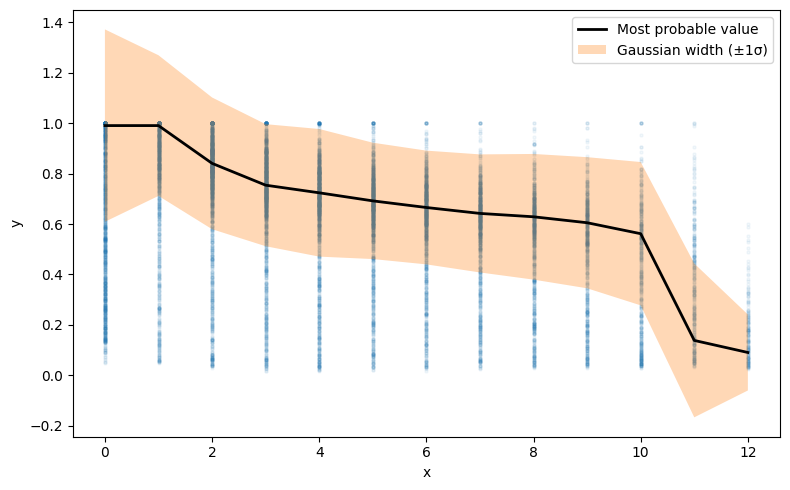

In [10]:
df = pd.DataFrame({"x": pr, "y": pE})
groups = df.groupby("x")["y"]

def sigma_from_data(y, mu):
    return np.sqrt(np.mean((y - mu)**2))

results = {}

for xval, yvals in groups:
    yvals = yvals.values

    if len(yvals) < 3:
        continue  # too little data to define a distribution

    from scipy.stats import gaussian_kde

    kde = gaussian_kde(yvals)
    ygrid = np.linspace(yvals.min(), yvals.max(), 500)
    
    mu = ygrid[np.argmax(kde(ygrid))]
    sigma = sigma_from_data(yvals, mu)

    results[xval] = {
        "mu": mu,
        "sigma": sigma
    }

from scipy.stats import norm

x0 = 10
mu = results[x0]["mu"]
sigma = results[x0]["sigma"]

ygrid = np.linspace(0, 1, 200)
pdf = norm.pdf(ygrid, mu, sigma)

xs = np.array(sorted(results.keys()))
mu = np.array([results[x]["mu"] for x in xs])
sigma = np.array([results[x]["sigma"] for x in xs])

plt.figure(figsize=(8, 5))

# raw data (very faint)
plt.scatter(pr, pE, s=5, alpha=0.05)

# most probable value
plt.plot(xs, mu, color='black', lw=2, label='Most probable value')

# ±1σ band
plt.fill_between(
    xs,
    mu - sigma,
    mu + sigma,
    alpha=0.3,
    label='Gaussian width (±1σ)'
)

plt.xlabel('x')
plt.ylabel('y')
plt.legend()
plt.tight_layout()
plt.show()

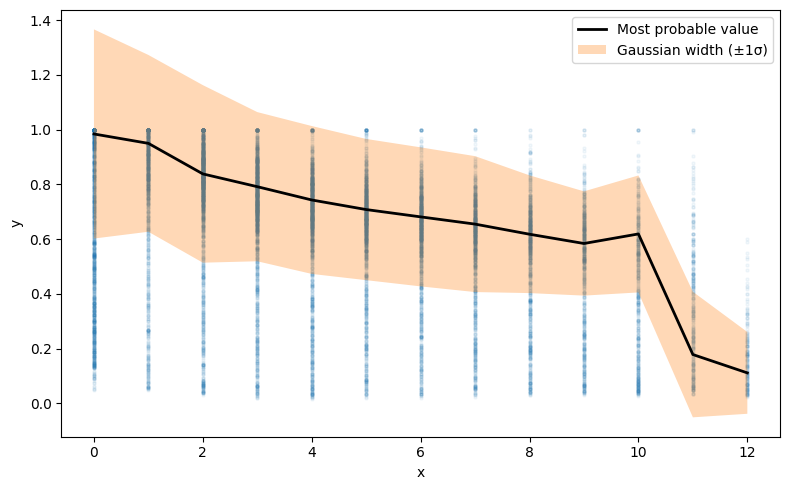

In [11]:
df = pd.DataFrame({"x": dr, "y": dE})
groups = df.groupby("x")["y"]

def sigma_from_data(y, mu):
    return np.sqrt(np.mean((y - mu)**2))

results = {}

for xval, yvals in groups:
    yvals = yvals.values

    if len(yvals) < 2:
        continue  # too little data to define a distribution

    from scipy.stats import gaussian_kde

    kde = gaussian_kde(yvals)
    ygrid = np.linspace(yvals.min(), yvals.max(), 500)
    
    mu = ygrid[np.argmax(kde(ygrid))]
    sigma = sigma_from_data(yvals, mu)

    results[xval] = {
        "mu": mu,
        "sigma": sigma
    }

from scipy.stats import norm

x0 = 10
mu = results[x0]["mu"]
sigma = results[x0]["sigma"]

ygrid = np.linspace(0, 1, 200)
pdf = norm.pdf(ygrid, mu, sigma)

xs = np.array(sorted(results.keys()))
mu = np.array([results[x]["mu"] for x in xs])
sigma = np.array([results[x]["sigma"] for x in xs])

plt.figure(figsize=(8, 5))

# raw data (very faint)
plt.scatter(pr, pE, s=5, alpha=0.05)

# most probable value
plt.plot(xs, mu, color='black', lw=2, label='Most probable value')

# ±1σ band
plt.fill_between(
    xs,
    mu - sigma,
    mu + sigma,
    alpha=0.3,
    label='Gaussian width (±1σ)'
)

plt.xlabel('x')
plt.ylabel('y')
plt.legend()
plt.tight_layout()
plt.show()

/Users/user/code/research/proton-deuteron/.venv/lib/python3.11/site-packages/scipy/_lib/_util.py:1272: RuntimeWarning: divide by zero encountered in vecdot
  return np.vecdot(x1, x2, axis=axis)
/Users/user/code/research/proton-deuteron/.venv/lib/python3.11/site-packages/scipy/_lib/_util.py:1272: RuntimeWarning: overflow encountered in vecdot
  return np.vecdot(x1, x2, axis=axis)
/Users/user/code/research/proton-deuteron/.venv/lib/python3.11/site-packages/scipy/_lib/_util.py:1272: RuntimeWarning: invalid value encountered in vecdot
  return np.vecdot(x1, x2, axis=axis)


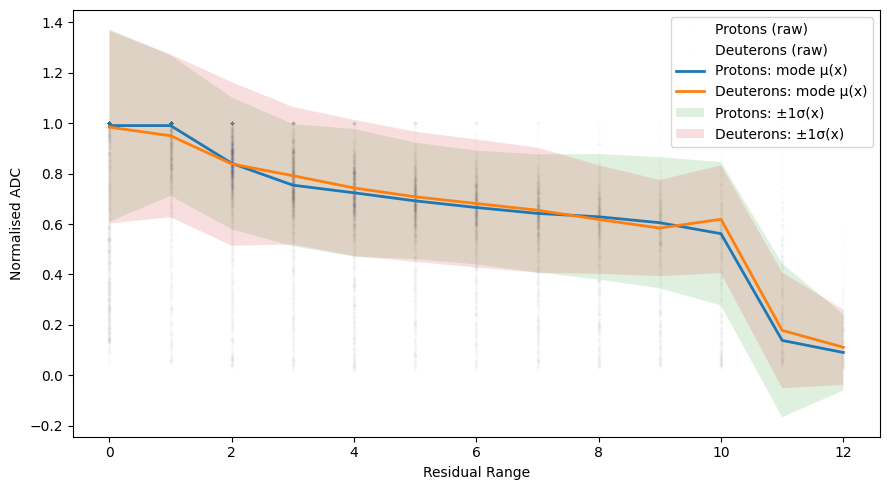

In [16]:
import numpy as np
import pandas as pd
from scipy.stats import gaussian_kde

def fit_conditional_gaussian(x, y, min_n=3, grid_n=500):
    df = pd.DataFrame({"x": x, "y": y})
    groups = df.groupby("x")["y"]

    def sigma_from_data(yvals, mu):
        return np.sqrt(np.mean((yvals - mu)**2))

    results = {}
    for xval, yvals in groups:
        yvals = yvals.values
        if len(yvals) < min_n:
            continue
        if np.all(yvals == yvals[0]):
            mu = float(yvals[0])
            sigma = 0.0
        else:
            kde = gaussian_kde(yvals)
            ygrid = np.linspace(yvals.min(), yvals.max(), grid_n)
            mu = float(ygrid[np.argmax(kde(ygrid))])
            sigma = float(sigma_from_data(yvals, mu))

        results[xval] = {"mu": mu, "sigma": sigma, "n": len(yvals)}

    xs = np.array(sorted(results.keys()))
    mu = np.array([results[x]["mu"] for x in xs])
    sigma = np.array([results[x]["sigma"] for x in xs])
    n = np.array([results[x]["n"] for x in xs])
    return xs, mu, sigma, n, results

xp, mup, sigp, npg, res_p = fit_conditional_gaussian(pr, pE, min_n=3)
xd, mud, sigd, ndg, res_d = fit_conditional_gaussian(dr, dE, min_n=3)

import matplotlib.pyplot as plt

plt.figure(figsize=(9, 5))

# Raw points (optional; can be heavy)
plt.scatter(pr, pE, s=4, alpha=0.003, label="Protons (raw)")
plt.scatter(dr, dE, s=4, alpha=0.003, label="Deuterons (raw)")

# Ridge lines
plt.plot(xp, mup, lw=2, label="Protons: mode μ(x)")
plt.plot(xd, mud, lw=2, label="Deuterons: mode μ(x)")

# Bands
plt.fill_between(xp, mup - sigp, mup + sigp, alpha=0.15, label="Protons: ±1σ(x)")
plt.fill_between(xd, mud - sigd, mud + sigd, alpha=0.15, label="Deuterons: ±1σ(x)")

plt.xlabel("Residual Range")
plt.ylabel("Normalised ADC")
plt.legend()
plt.tight_layout()
plt.show()

This might just be impossible, they're too close together.